<a href="https://colab.research.google.com/github/dinoanakin2007/Mobile_price_predictor/blob/main/mobile_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import os

print(os.listdir("/content"))

['.config', '.ipynb_checkpoints', 'mobile_kaggle.zip', 'sample_data']


In [ ]:
import zipfile

zip_path = "/content/mobile_kaggle.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/mobile_dataset")

print("✅ ZIP extracted successfully!")

✅ ZIP extracted successfully!


In [ ]:
print(os.listdir("/content/mobile_dataset"))


['Mobile Price Prediction Datatset.csv']


In [ ]:
df = pd.read_csv(
    "/content/mobile_dataset/Mobile Price Prediction Datatset.csv"
)

print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (836, 10)


In [ ]:
print("Column names:")
print(df.columns.tolist())

Column names:
['Unnamed: 0', 'Brand me', 'Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power', 'Price']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     836 non-null    int64  
 1   Brand me       836 non-null    object 
 2   Ratings        805 non-null    float64
 3   RAM            829 non-null    float64
 4   ROM            832 non-null    float64
 5   Mobile_Size    834 non-null    float64
 6   Primary_Cam    836 non-null    int64  
 7   Selfi_Cam      567 non-null    float64
 8   Battery_Power  836 non-null    int64  
 9   Price          836 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 65.4+ KB


In [ ]:
df.describe()

,Unnamed: 0,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
count,836.000000,805.000000,829.000000,832.000000,834.000000,836.000000,567.000000,836.000000,836.00000
mean,417.500000,4.103106,6.066345,64.373077,5.597282,47.983254,9.784832,3274.688995,18220.34689
std,241.476707,0.365356,2.530336,53.447825,3.898664,11.170093,6.503838,927.518852,52805.55022
min,0.000000,2.800000,0.000000,0.000000,2.000000,5.000000,0.000000,1020.000000,479.00000
25%,208.750000,3.800000,6.000000,32.000000,4.500000,48.000000,5.000000,3000.000000,984.75000
50%,417.500000,4.100000,6.000000,40.000000,4.770000,48.000000,8.000000,3000.000000,1697.00000
75%,626.250000,4.400000,6.000000,64.000000,6.300000,48.000000,13.000000,3800.000000,18999.00000
max,835.000000,4.800000,34.000000,256.000000,44.000000,64.000000,61.000000,6000.000000,573000.00000


In [ ]:
df = df.drop("Unnamed: 0", axis=1, errors="ignore")

In [ ]:
print(df.columns.tolist())

['Brand me', 'Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power', 'Price']


In [ ]:
print(df.isnull().sum())

Brand me           0
Ratings           31
RAM                7
ROM                4
Mobile_Size        2
Primary_Cam        0
Selfi_Cam        269
Battery_Power      0
Price              0
dtype: int64


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 206


In [ ]:
df = df.drop_duplicates()

print("New shape:", df.shape)

New shape: (630, 9)


In [ ]:
print("Number of brands:", df["Brand me"].nunique())

Number of brands: 427


In [ ]:
print(df["Brand me"].unique())

['LG V30+ (Black, 128 )' 'I Kall K11' 'Nokia 105 ss'
 'Samsung Galaxy A50 (White, 64 )' 'POCO F1 (Steel Blue, 128 )'
 'Apple iPhone 11 Pro (Space Grey, 512 )'
 'Samsung Galaxy A70s (Prism Crush Red, 128 )'
 'Samsung Galaxy S10 Lite (Prism Blue, 512 )'
 'OPPO A9 (Marble Green, 128 )' 'POCO F1 (Graphite Black, 256 )'
 'Megus Ultra' 'Jmax M40 Coo of Two' 'Wizphone WP (Black, 16 )'
 'Easyfone Star' 'OnePlus 7 Pro (Nebula Blue, 256 )'
 'OnePlus 7 Pro (Mirror Grey, 128 )' 'Kechaoda A27'
 'Samsung Galaxy S20+ (Cloud Blue, 128 )'
 'Samsung Galaxy S10 Lite (Prism Black, 512 )' 'OPPO A5s (Red, 32 )'
 'InFocus POWER 2' 'Blacear I7 Trio' 'Karbonn K451 Power' 'Micax X742'
 'Snexian Guru 332' 'Blacear i7 Trio' 'Karbonn K334' 'Lava Prime X'
 'I Kall K23 New Mobile' 'InFocus Selfie C1' 'LG G8X (Black, 128 )'
 'Gee A1 (Grey, 64 )' 'Tecno Camon 15 Pro (Opal White, 128 )' 'Lava A7'
 'Apple iPhone XR ((PRODUCT)RED, 128 )' 'Micax X749' 'Itel it2161'
 'Karbonn K-Pebble' 'Karbonn KX21' 'Inovu A9' 'LG Q Stylu

In [ ]:
df["Brand me"].value_counts()

,count
Brand me,
Kechaoda A27,10
Easyfone Star,8
Nokia 3310 DS,5
Micax X749,5
I Kall K11,5
...,...
"Samsung Galaxy S20+ (Cloud Blue, 128 )",1
"Samsung Galaxy S10 Lite (Prism Black, 512 )",1
"OPPO A5s (Red, 32 )",1


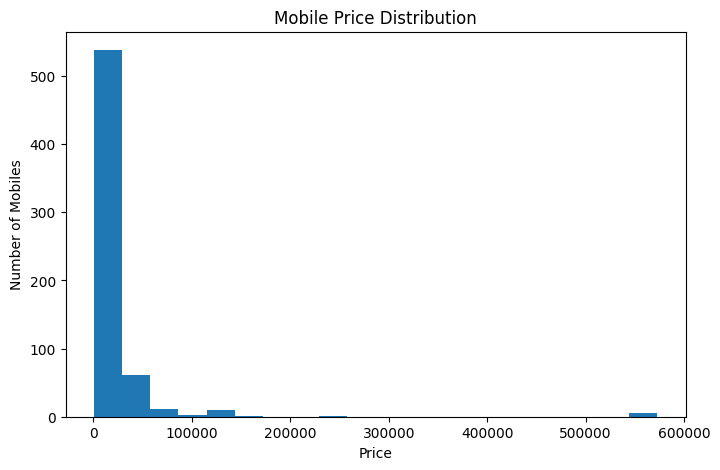

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=20)

plt.xlabel("Price")
plt.ylabel("Number of Mobiles")
plt.title("Mobile Price Distribution")

plt.show()

In [ ]:
correlation = df.select_dtypes(include="number").corr()["Price"].sort_values(
    ascending=False
)

print(correlation)

Price            1.000000
Ratings          0.357999
ROM              0.246241
RAM              0.234657
Battery_Power    0.159508
Mobile_Size      0.033136
Selfi_Cam       -0.065225
Primary_Cam     -0.167940
Name: Price, dtype: float64


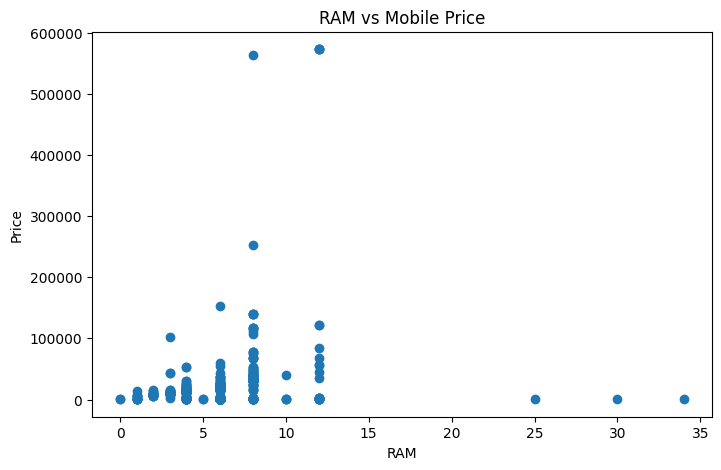

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["RAM"], df["Price"])

plt.xlabel("RAM")
plt.ylabel("Price")
plt.title("RAM vs Mobile Price")

plt.show()

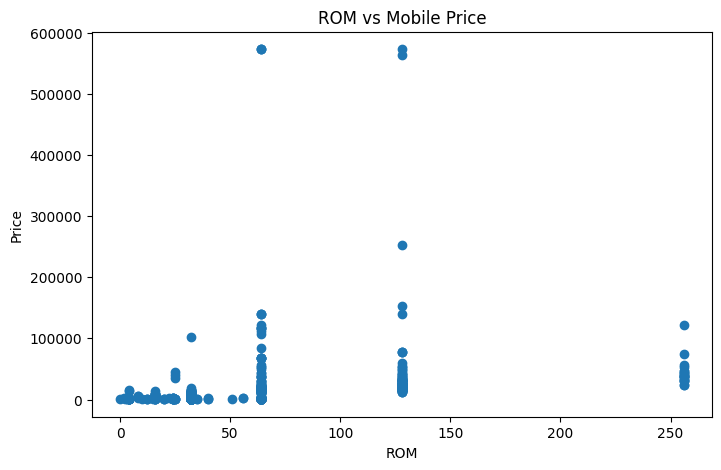

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["ROM"], df["Price"])

plt.xlabel("ROM")
plt.ylabel("Price")
plt.title("ROM vs Mobile Price")

plt.show()

In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [ ]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Brand me', 'Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power']

Target:
Price


In [ ]:
categorical_features = ["Brand me"]

numerical_features = [
    "Ratings",
    "RAM",
    "ROM",
    "Mobile_Size",
    "Primary_Cam",
    "Selfi_Cam",
    "Battery_Power"
]

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (504, 8)
Testing data: (126, 8)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model_lr = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [ ]:
model_lr.fit(X_train, y_train)

print("✅ Linear Regression trained successfully!")

✅ Linear Regression trained successfully!


In [ ]:
y_pred_lr = model_lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("----------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
----------------------
MAE : 9461.390087146236
RMSE: 15596.033104545339
R²  : 0.4996703769262767


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

In [ ]:
model_rf.fit(X_train, y_train)

print("✅ Random Forest trained successfully!")

✅ Random Forest trained successfully!


In [ ]:
y_pred_rf = model_rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("----------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
----------------------
MAE : 3211.618228479046
RMSE: 10373.11929021053
R²  : 0.7786667481259608


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9461.390087,15596.033105,0.499670
1,Random Forest,3211.618228,10373.119290,0.778667


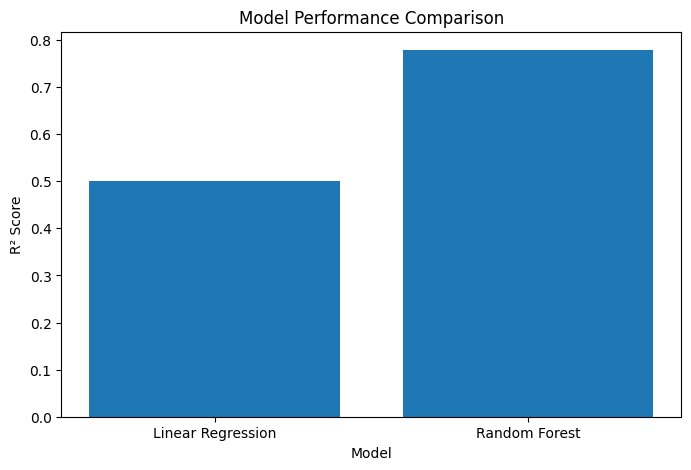

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2 Score"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.show()

In [ ]:
best_model = model_rf

print("🏆 Best Model: Random Forest")
print("R² Score:", r2_rf)

🏆 Best Model: Random Forest
R² Score: 0.7786667481259608


In [ ]:
sample_phone = X_test.iloc[[0]]

actual_price = y_test.iloc[0]

predicted_price = best_model.predict(sample_phone)[0]

print("Actual Price:", actual_price)
print("Predicted Price:", round(predicted_price, 2))

Actual Price: 930
Predicted Price: 1006.88


In [ ]:
error = abs(actual_price - predicted_price)

print("Prediction Error:", round(error, 2))

Prediction Error: 76.88


In [ ]:
print(df["Brand me"].unique())

['LG V30+ (Black, 128 )' 'I Kall K11' 'Nokia 105 ss'
 'Samsung Galaxy A50 (White, 64 )' 'POCO F1 (Steel Blue, 128 )'
 'Apple iPhone 11 Pro (Space Grey, 512 )'
 'Samsung Galaxy A70s (Prism Crush Red, 128 )'
 'Samsung Galaxy S10 Lite (Prism Blue, 512 )'
 'OPPO A9 (Marble Green, 128 )' 'POCO F1 (Graphite Black, 256 )'
 'Megus Ultra' 'Jmax M40 Coo of Two' 'Wizphone WP (Black, 16 )'
 'Easyfone Star' 'OnePlus 7 Pro (Nebula Blue, 256 )'
 'OnePlus 7 Pro (Mirror Grey, 128 )' 'Kechaoda A27'
 'Samsung Galaxy S20+ (Cloud Blue, 128 )'
 'Samsung Galaxy S10 Lite (Prism Black, 512 )' 'OPPO A5s (Red, 32 )'
 'InFocus POWER 2' 'Blacear I7 Trio' 'Karbonn K451 Power' 'Micax X742'
 'Snexian Guru 332' 'Blacear i7 Trio' 'Karbonn K334' 'Lava Prime X'
 'I Kall K23 New Mobile' 'InFocus Selfie C1' 'LG G8X (Black, 128 )'
 'Gee A1 (Grey, 64 )' 'Tecno Camon 15 Pro (Opal White, 128 )' 'Lava A7'
 'Apple iPhone XR ((PRODUCT)RED, 128 )' 'Micax X749' 'Itel it2161'
 'Karbonn K-Pebble' 'Karbonn KX21' 'Inovu A9' 'LG Q Stylu

In [ ]:
print(df[numerical_features].describe())

          Ratings         RAM         ROM  Mobile_Size  Primary_Cam  \
count  608.000000  624.000000  626.000000   628.000000   630.000000   
mean     4.078289    6.088141   61.407987     5.646947    47.682540   
std      0.370034    2.654580   50.361982     4.457862    11.227557   
min      2.800000    0.000000    0.000000     2.000000     5.000000   
25%      3.800000    6.000000   32.000000     4.500000    48.000000   
50%      4.100000    6.000000   32.000000     4.580000    48.000000   
75%      4.400000    6.000000   64.000000     6.220000    48.000000   
max      4.800000   34.000000  256.000000    44.000000    64.000000   

        Selfi_Cam  Battery_Power  
count  437.000000     630.000000  
mean    10.121281    3242.571429  
std      6.720599     925.853222  
min      0.000000    1020.000000  
25%      5.000000    3000.000000  
50%      8.000000    3000.000000  
75%     13.000000    3800.000000  
max     61.000000    6000.000000  


In [ ]:
new_mobile = pd.DataFrame({
    "Brand me": ["Samsung"],
    "Ratings": [4.3],
    "RAM": [8],
    "ROM": [128],
    "Mobile_Size": [6.5],
    "Primary_Cam": [50],
    "Selfi_Cam": [16],
    "Battery_Power": [5000]
})

In [ ]:
predicted_price = best_model.predict(new_mobile)[0]

print("Estimated Mobile Price:", round(predicted_price, 2))

Estimated Mobile Price: 23447.43


In [ ]:
import joblib

joblib.dump(
    best_model,
    "mobile_price_prediction_model.pkl"
)

print("✅ Complete model saved successfully!")

✅ Complete model saved successfully!


In [ ]:
from google.colab import files

files.download("mobile_price_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model_lr.fit(X_train, y_train)
print("✅ Linear Regression trained successfully!")

✅ Linear Regression trained successfully!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_lr = model_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("----------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
----------------------
MAE : 9461.390087146236
RMSE: 15596.033104545339
R²  : 0.4996703769262767


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]
)

model_rf.fit(X_train, y_train)

print("✅ Random Forest trained successfully!")

✅ Random Forest trained successfully!


In [ ]:
y_pred_rf = model_rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("----------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
----------------------
MAE : 3211.618228479046
RMSE: 10373.11929021053
R²  : 0.7786667481259608


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

model_gb.fit(X_train, y_train)

print("✅ Gradient Boosting trained successfully!")

✅ Gradient Boosting trained successfully!


In [ ]:
y_pred_gb = model_gb.predict(X_test)

In [ ]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("----------------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting
----------------------
MAE : 3989.5279824056306
RMSE: 10929.366381331201
R²  : 0.7542927959329893


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_lr,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_gb
    ],
    "R2 Score": [
        r2_lr,
        r2_rf,
        r2_gb
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9461.390087,15596.033105,0.499670
1,Random Forest,3211.618228,10373.119290,0.778667
2,Gradient Boosting,3989.527982,10929.366381,0.754293


In [ ]:
best_index = results["R2 Score"].idxmax()

best_model_name = results.loc[best_index, "Model"]

best_r2 = results.loc[best_index, "R2 Score"]

print("🏆 BEST MODEL:", best_model_name)
print("🏆 R² SCORE:", best_r2)

🏆 BEST MODEL: Random Forest
🏆 R² SCORE: 0.7786667481259608


In [ ]:
models = {
    "Linear Regression": model_lr,
    "Random Forest": model_rf,
    "Gradient Boosting": model_gb
}

best_model = models[best_model_name]

print("✅ Best model selected!")

✅ Best model selected!


In [ ]:
sample_phone = X_test.iloc[[0]]

actual_price = y_test.iloc[0]

predicted_price = best_model.predict(sample_phone)[0]

print("Actual Price:", actual_price)
print("Predicted Price:", round(predicted_price, 2))

Actual Price: 930
Predicted Price: 1006.88


In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr

print("✅ Gradio imported successfully!")

✅ Gradio imported successfully!


In [ ]:
brands = sorted(df["Brand me"].dropna().unique().tolist())

print(brands)

['Alcatel 1 (Metallic Black, 8 )', 'Alcatel 1 (Metallic Blue, 8 )', 'Alcatel 5V (Spectrum Black, 32 )', 'Alcatel 5V (Spectrum Blue, 32 )', 'Apple iPhone 11 (Red, 64 )', 'Apple iPhone 11 (Yellow, 64 )', 'Apple iPhone 11 Pro (Gold, 64 )', 'Apple iPhone 11 Pro (Silver, 512 )', 'Apple iPhone 11 Pro (Space Grey, 256 )', 'Apple iPhone 11 Pro (Space Grey, 512 )', 'Apple iPhone 11 Pro Max (Gold, 64 )', 'Apple iPhone 11 Pro Max (Silver, 64 )', 'Apple iPhone 11 Pro Max (Space Grey, 64 )', 'Apple iPhone 6s (Space Grey, 32 )', 'Apple iPhone 7 Plus (Gold, 32 )', 'Apple iPhone 7 Plus (Rose Gold, 32 )', 'Apple iPhone 7 Plus (Silver, 32 )', 'Apple iPhone 8 (PRODUCT)RED (Red, 256 )', 'Apple iPhone 8 (Silver, 64 )', 'Apple iPhone 8 (Space Grey, 64 )', 'Apple iPhone 8 Plus (Gold, 256 )', 'Apple iPhone 8 Plus (Gold, 64 )', 'Apple iPhone XR ((PRODUCT)RED, 128 )', 'Apple iPhone XR (Coral, 128 )', 'Apple iPhone XR (Yellow, 128 )', 'Apple iPhone XS (Silver, 256 )', 'Apple iPhone XS (Silver, 512 )', 'Blacear B

In [ ]:
def predict_price(
    brand,
    ratings,
    ram,
    rom,
    mobile_size,
    primary_cam,
    selfie_cam,
    battery_power
):

    input_data = pd.DataFrame({
        "Brand me": [brand],
        "Ratings": [ratings],
        "RAM": [ram],
        "ROM": [rom],
        "Mobile_Size": [mobile_size],
        "Primary_Cam": [primary_cam],
        "Selfi_Cam": [selfie_cam],
        "Battery_Power": [battery_power]
    })

    prediction = best_model.predict(input_data)[0]

    return f"₹{prediction:,.2f}"

In [ ]:
import gradio as gr

# Prediction function
def predict_price(
    brand,
    ratings,
    ram,
    rom,
    mobile_size,
    primary_cam,
    selfie_cam,
    battery_power
):

    input_data = pd.DataFrame({
        "Brand me": [brand],
        "Ratings": [ratings],
        "RAM": [ram],
        "ROM": [rom],
        "Mobile_Size": [mobile_size],
        "Primary_Cam": [primary_cam],
        "Selfi_Cam": [selfie_cam],
        "Battery_Power": [battery_power]
    })

    prediction = best_model.predict(input_data)[0]

    return f"₹ {prediction:,.2f}"


# Custom CSS
custom_css = """
body {
    background: #f5f7fb;
}

.gradio-container {
    max-width: 1100px !important;
    margin: auto !important;
}

.header {
    text-align: center;
    padding: 25px;
}

.title {
    font-size: 36px !important;
    font-weight: 700 !important;
}

.subtitle {
    font-size: 17px !important;
    color: #666 !important;
}

.card {
    border-radius: 18px !important;
    padding: 20px !important;
}

.predict-btn {
    font-size: 18px !important;
    font-weight: bold !important;
    height: 55px !important;
}

.price-box {
    font-size: 28px !important;
    font-weight: bold !important;
    text-align: center !important;
}
"""


with gr.Blocks(
    theme=gr.themes.Soft(),
    css=custom_css,
    title="Mobile Price Predictor"
) as demo:

    # HEADER
    gr.HTML("""
    <div class="header">
        <div class="title">📱 Mobile Price Predictor</div>
        <div class="subtitle">
            Predict the estimated price of a smartphone using Machine Learning
        </div>
    </div>
    """)

    gr.Markdown(
        """
        ### 🔍 Enter Mobile Specifications
        Provide the specifications below and our trained ML model
        will estimate the mobile's price.
        """
    )

    with gr.Row():

        # LEFT COLUMN
        with gr.Column(elem_classes="card"):

            gr.Markdown("### 📱 Device Information")

            brand = gr.Dropdown(
                choices=brands,
                label="🏷️ Brand",
                value=brands[0]
            )

            ratings = gr.Number(
                label="⭐ Rating",
                value=float(df["Ratings"].median())
            )

            mobile_size = gr.Number(
                label="📐 Mobile Size",
                value=float(df["Mobile_Size"].median())
            )

        # RIGHT COLUMN
        with gr.Column(elem_classes="card"):

            gr.Markdown("### ⚙️ Hardware Specifications")

            ram = gr.Number(
                label="🧠 RAM",
                value=float(df["RAM"].median())
            )

            rom = gr.Number(
                label="💾 ROM / Storage",
                value=float(df["ROM"].median())
            )

            battery_power = gr.Number(
                label="🔋 Battery Power",
                value=float(df["Battery_Power"].median())
            )

    with gr.Row():

        with gr.Column(elem_classes="card"):

            gr.Markdown("### 📷 Camera")

            primary_cam = gr.Number(
                label="📸 Primary Camera",
                value=float(df["Primary_Cam"].median())
            )

            selfie_cam = gr.Number(
                label="🤳 Selfie Camera",
                value=float(df["Selfi_Cam"].median())
            )

    # BUTTON
    predict_button = gr.Button(
        "🔮  PREDICT MOBILE PRICE",
        variant="primary",
        elem_classes="predict-btn"
    )

    # RESULT
    gr.Markdown("### 💰 Estimated Price")

    output = gr.Textbox(
        label="Prediction",
        placeholder="Your estimated price will appear here...",
        elem_classes="price-box"
    )

    predict_button.click(
        fn=predict_price,
        inputs=[
            brand,
            ratings,
            ram,
            rom,
            mobile_size,
            primary_cam,
            selfie_cam,
            battery_power
        ],
        outputs=output
    )

    gr.Markdown(
        """
        ---
        **🤖 Machine Learning Model:** Best performing regression model
        **📊 Dataset:** Mobile Price Dataset
        **⚡ Interface:** Gradio
        """
    )


demo.launch(share=True)

/tmp/ipykernel_1313/3083517001.py:76: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://781ee0966ce58fc854.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
